In [1]:
#setting up the notebook
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns

In [3]:
#reading the csv file
df= pd.read_csv('C:/Users/Lenovo/OneDrive/Desktop/BinX training/Project/data/medicaldataset.csv')

In [4]:
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   str    
dtypes: float64(3), int64(5), str(1)
memory usage: 92.9 KB


In [12]:
#checking duplicates
print(df.duplicated().sum())

0


There is no null values, no duplicates, no categorical value except the target value which is the result so no need for encoding
Gender is already encoded (0 = Female , 1 = Male)
All are numerical values that need scaling before training 

In [ ]:
df.describe()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


This is a heart Attack data set the target column is (Result) whether this patient had a heart attack according to his\her data or not 
(positive or negative)

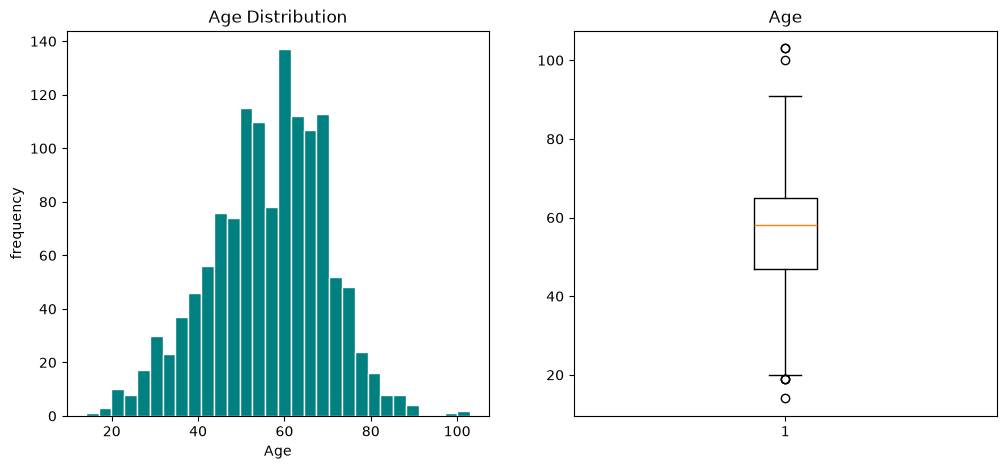

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Age'],bins=30, color='teal', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_ylabel('frequency')
axes[0].set_xlabel('Age')


axes[1].boxplot(df['Age'])
axes[1].set_title('Age')


plt.show()


Age has normal distribution and has outliers won't be deleted since its's in acceptable range

Text(0, 0.5, 'frequency')

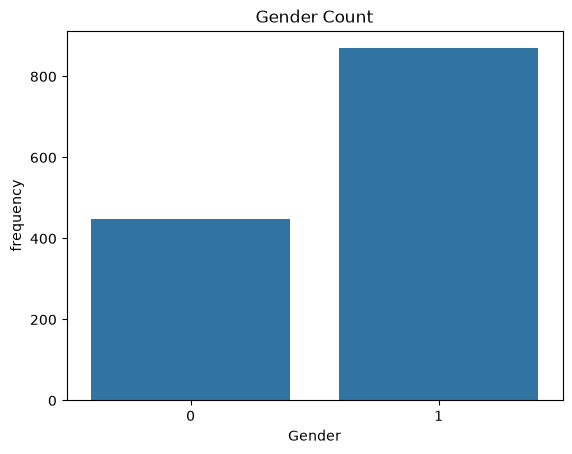

In [43]:
sns.countplot(data=df, x='Gender')
plt.title('Gender Count')
plt.ylabel('frequency')

classification (0 for female), (1 for male)

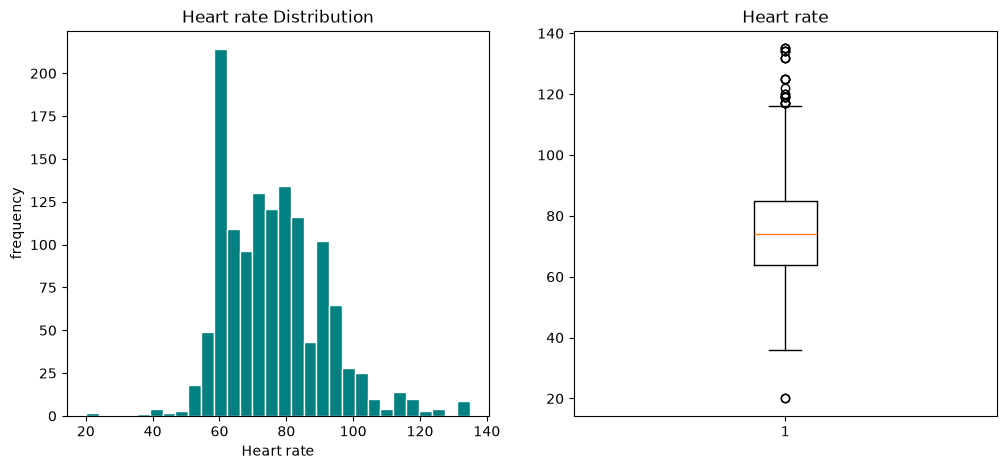

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Heart rate'],bins=30, color='teal', edgecolor='white')
axes[0].set_title('Heart rate Distribution')
axes[0].set_ylabel('frequency')
axes[0].set_xlabel('Heart rate')


axes[1].boxplot(df['Heart rate'])
axes[1].set_title('Heart rate')


plt.show()


Heart Rate has normal distribution with some outliers

**Finding:** A resting heart rate of **1111 bpm** is not physiologically possible for a living
person (realistic human heart rate range is roughly 20–250 bpm even in extreme medical conditions).
This is almost certainly a **data entry error** — likely a stray digit or unit mistake, not a real
measurement.

Heart Rate above than 250 should be deleted 


In [21]:
df[df['Heart rate']>250]

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result


In [ ]:
df=df[df['Heart rate']<=250]

Text(0, 0.5, 'frequency')

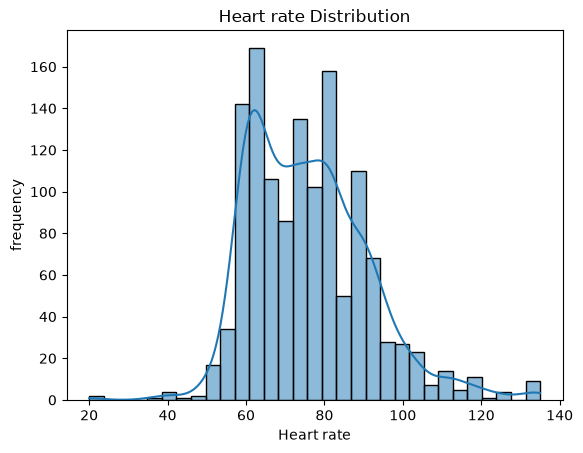

In [46]:
# Heart Rate Distribution after removing outliers
sns.histplot(df['Heart rate'], kde=True)
plt.title('Heart rate Distribution')
plt.ylabel('frequency')

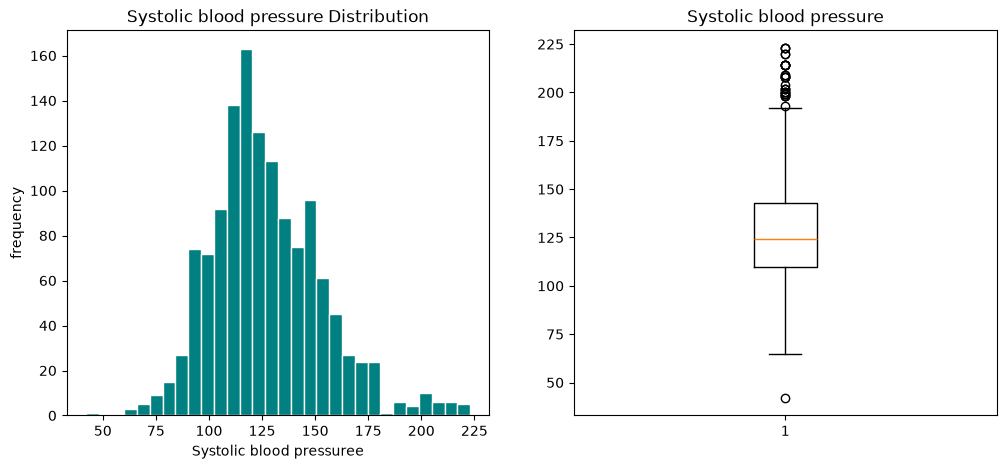

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Systolic blood pressure'],bins=30, color='teal', edgecolor='white')
axes[0].set_title('Systolic blood pressure Distribution')
axes[0].set_ylabel('frequency')
axes[0].set_xlabel('Systolic blood pressuree')


axes[1].boxplot(df['Systolic blood pressure'])
axes[1].set_title('Systolic blood pressure')


plt.show()


Systolic blood pressure has normal distribution

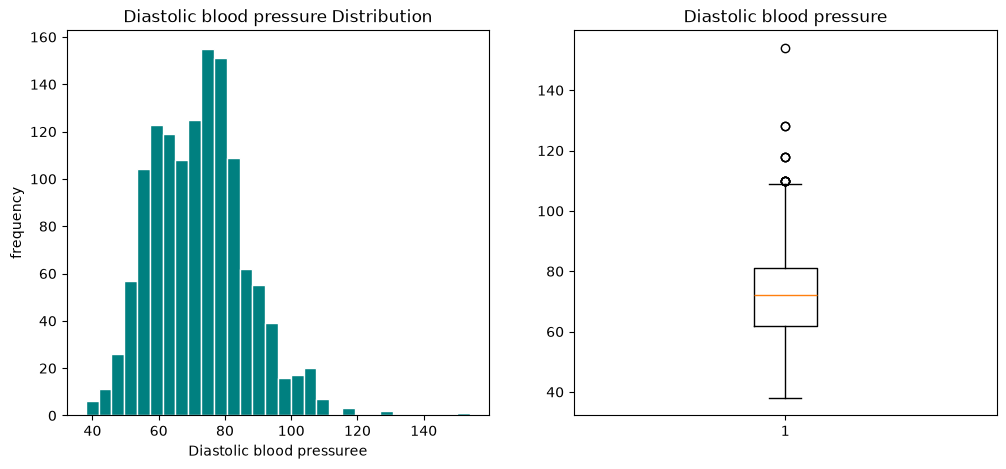

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Diastolic blood pressure'],bins=30, color='teal', edgecolor='white')
axes[0].set_title('Diastolic blood pressure Distribution')
axes[0].set_ylabel('frequency')
axes[0].set_xlabel('Diastolic blood pressuree')


axes[1].boxplot(df['Diastolic blood pressure'])
axes[1].set_title('Diastolic blood pressure')


plt.show()

Diastolic blood pressure has normal distribution and has outliers

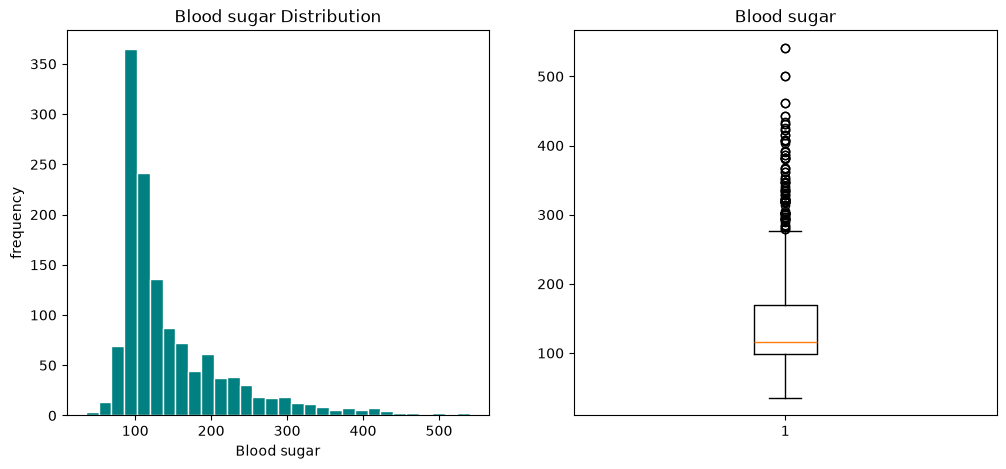

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Blood sugar'],bins=30, color='teal', edgecolor='white')
axes[0].set_title('Blood sugar Distribution')
axes[0].set_ylabel('frequency')
axes[0].set_xlabel('Blood sugar')


axes[1].boxplot(df['Blood sugar'])
axes[1].set_title('Blood sugar')


plt.show()

Blood Suger is skewed right and has outliers

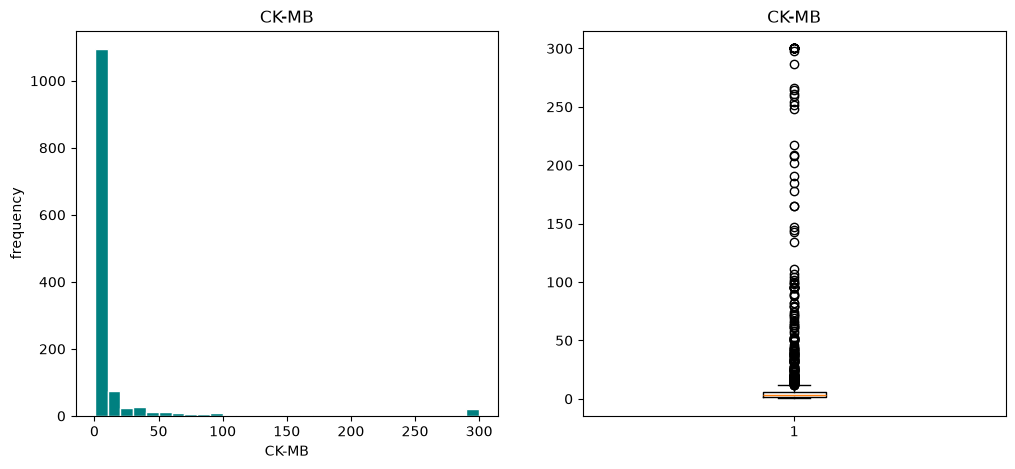

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['CK-MB'],bins=30, color='teal', edgecolor='white')
axes[0].set_title('CK-MB')
axes[0].set_ylabel('frequency')
axes[0].set_xlabel('CK-MB')


axes[1].boxplot(df['CK-MB'])
axes[1].set_title('CK-MB')


plt.show()

CK-MB is skewed right and has outliers

Text(0.5, 1.0, 'Troponin')

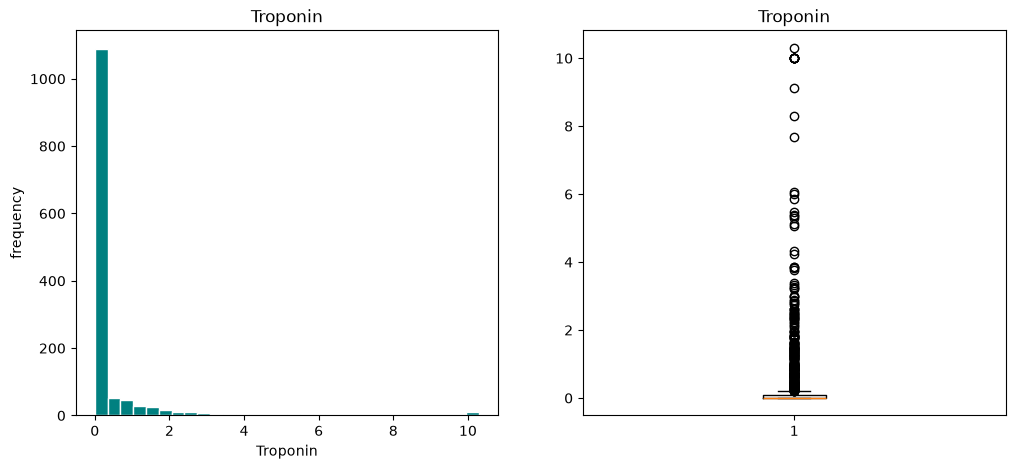

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Troponin'],bins=30, color='teal', edgecolor='white')
axes[0].set_title('Troponin')
axes[0].set_ylabel('frequency')
axes[0].set_xlabel('Troponin')


axes[1].boxplot(df['Troponin'])
axes[1].set_title('Troponin')


Troponin is skewed right and has outliers

Text(0.5, 1.0, 'Result Count')

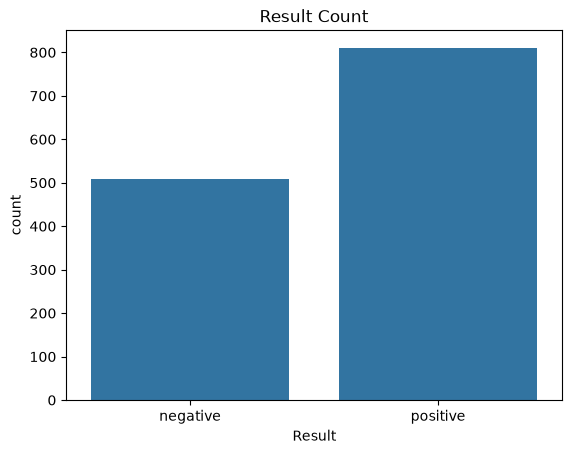

In [13]:
sns.countplot(data=df, x='Result')
plt.title('Result Count')

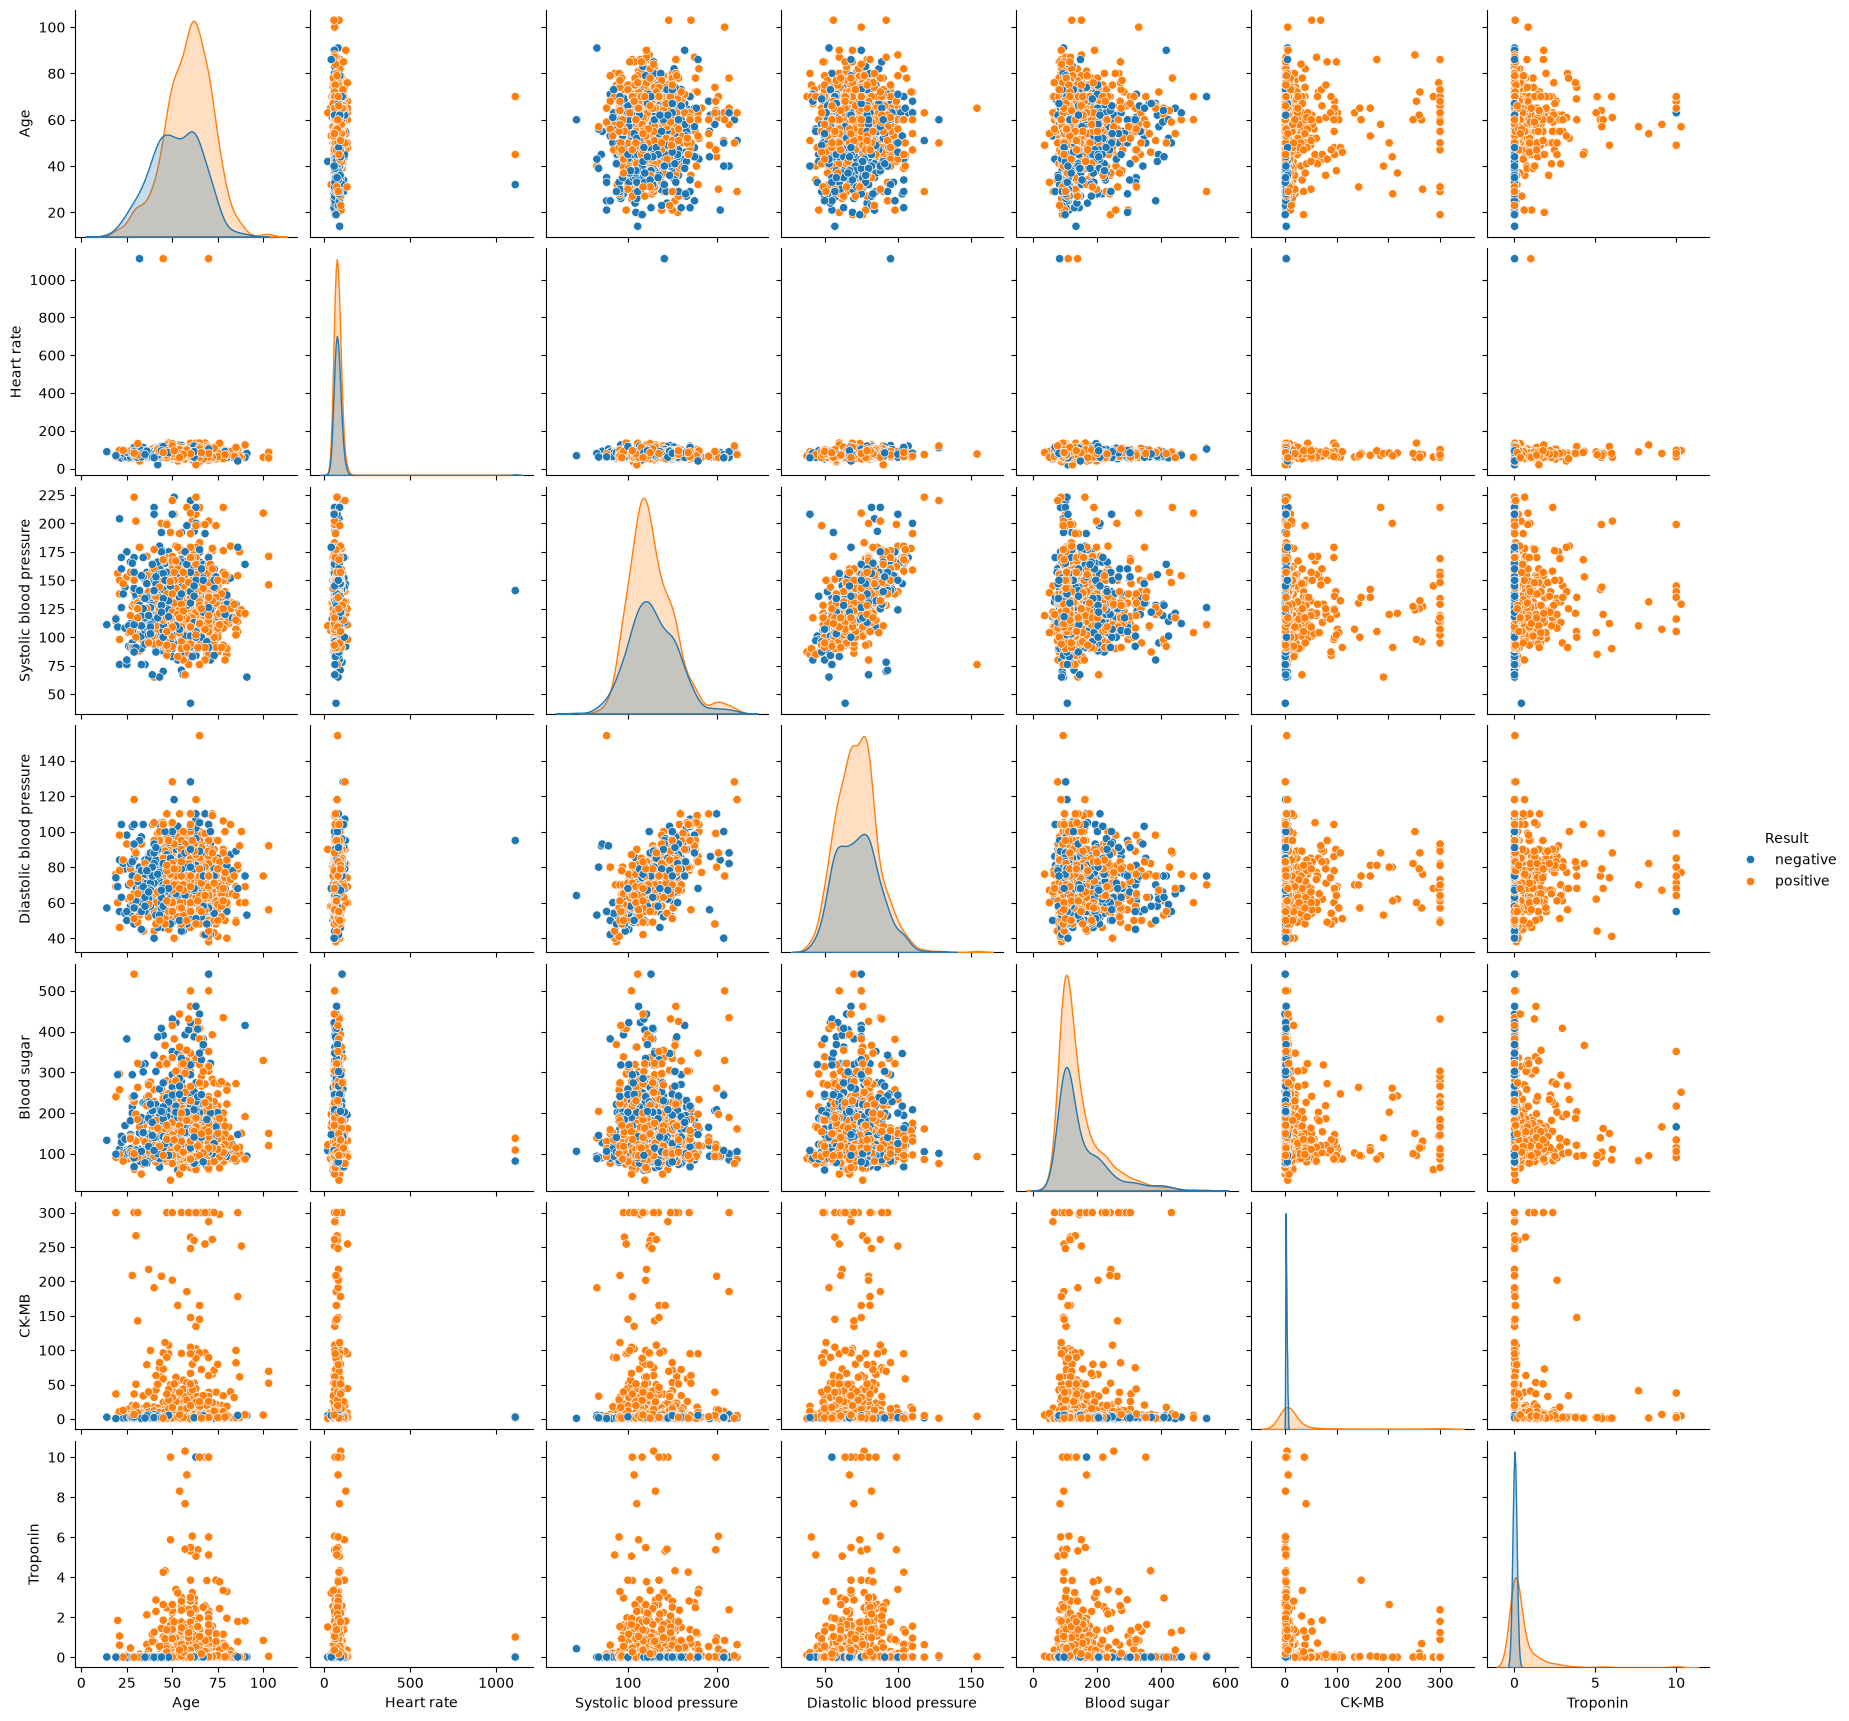

In [ ]:
sns.pairplot(df,x_vars=['Age', 'Heart rate', 'Systolic blood pressure',
       'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin'],y_vars= ['Age', 'Heart rate', 'Systolic blood pressure',
       'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin'], hue='Result')

In [29]:
df.groupby('Result')[['CK-MB', 'Troponin']].describe()

CK-MB                                                             \
          count       mean        std    min   25%    50%      75%     max   
Result                                                                       
negative  508.0   2.555138   1.368889  0.321  1.50  2.295   3.3525    7.02   
positive  808.0  23.317994  57.765013  0.353  1.87  3.775  12.2700  300.00   

         Troponin                                                          
            count      mean       std    min    25%    50%      75%   max  
Result                                                                     
negative    508.0  0.027026  0.443756  0.001  0.003  0.006  0.00900  10.0  
positive    808.0  0.570926  1.392209  0.003  0.016  0.044  0.45475  10.3

**Interpretation:** If median/mean CK-MB and Troponin are clearly higher in the `positive` group,
these "outliers" are informative signal, not noise they should be kept, and log-transformation
(not removal) is the right tool if a model later needs less skewed inputs.

we log-transform skewed variables so models that assume normally-distributed (or at least symmetric, non-extreme) inputs can learn more reliable patterns, without a few extreme values dominating the result."

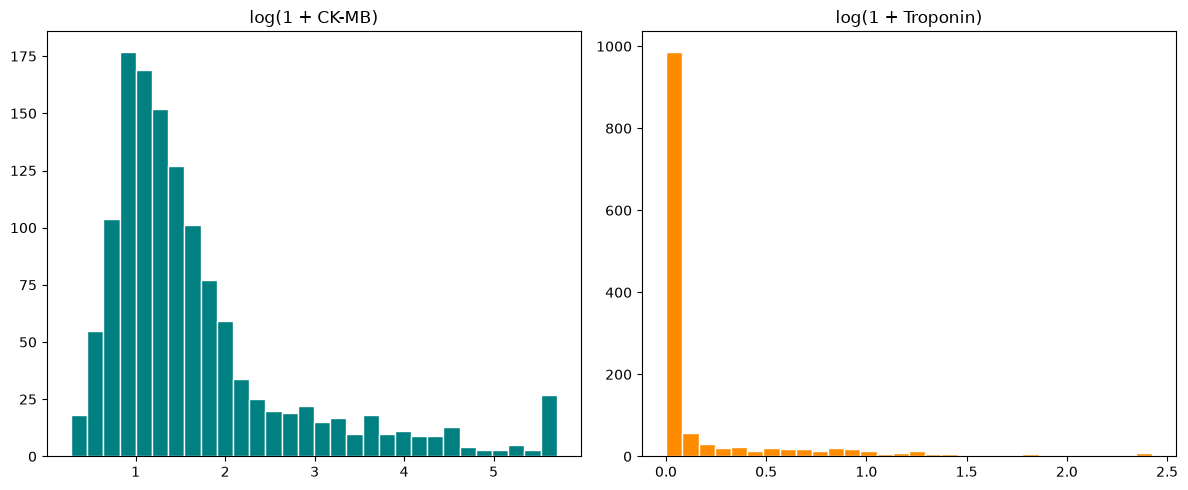

In [ ]:
# Log-transform view check
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(np.log1p(df['CK-MB']), bins=30, color='teal', edgecolor='white')
axes[0].set_title('log(1 + CK-MB)')

axes[1].hist(np.log1p(df['Troponin']), bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('log(1 + Troponin)')


plt.show()

In [53]:
df.to_csv('../data/heart_disease_clean.csv', index=False)
